In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
np.set_printoptions(precision=4, suppress=True)

In [2]:
A = np.array([[4, -5, 0],
              [0.6, 5, 0.6],
              [0, 0.5, 3]])
lam = np.linalg.eigvals(A)
print("Original eigenvalues (lam):", lam)

Original eigenvalues (lam): [4.5307+1.5953j 4.5307-1.5953j 2.9386+0.j    ]


In [3]:
# Part (a) Shift
sigma = 2.5
new_A = A + sigma * np.eye(3)
print(new_A)

new_lam = np.linalg.eigvals(new_A)
print("New eigenvalues (new_lam):", new_lam)

new_lam_without_numpy = lam + sigma
print("New eigenvalues without numpy:", new_lam_without_numpy)

[[ 6.5 -5.   0. ]
 [ 0.6  7.5  0.6]
 [ 0.   0.5  5.5]]
New eigenvalues (new_lam): [7.0307+1.5953j 7.0307-1.5953j 5.4386+0.j    ]
New eigenvalues without numpy: [7.0307+1.5953j 7.0307-1.5953j 5.4386+0.j    ]


In [4]:
# Part (b) Inversion
A_inv = np.linalg.inv(A)
print(A_inv)

new_lam = np.linalg.eigvals(A_inv)
print("New eigenvalues (new_lam):", new_lam)

new_lam_without_numpy = 1 / lam
print("New eigenvalues without numpy:", new_lam_without_numpy)

[[ 0.2168  0.2212 -0.0442]
 [-0.0265  0.177  -0.0354]
 [ 0.0044 -0.0295  0.3392]]
New eigenvalues (new_lam): [0.1964+0.0691j 0.1964-0.0691j 0.3403+0.j    ]
New eigenvalues without numpy: [0.1964-0.0691j 0.1964+0.0691j 0.3403+0.j    ]


In [5]:
# Part (c) Power 
A_power = np.linalg.matrix_power(A, 3)
print(A_power)

new_lam = np.linalg.eigvals(A_power)
print("New eigenvalues (new_lam):", new_lam)

new_lam_without_numpy = lam**3
print("New eigenvalues without numpy:", new_lam_without_numpy)

[[  25.   -291.5   -36.  ]
 [  34.98   86.9    27.78]
 [   3.6    23.15   30.3 ]]
New eigenvalues (new_lam): [58.4117+94.1792j 58.4117-94.1792j 25.3765 +0.j    ]
New eigenvalues without numpy: [58.4117+94.1792j 58.4117-94.1792j 25.3765 +0.j    ]


In [6]:
# Problem 2
def power_iteration(A, x0, tol=1e-8, max_iter=1000):
    x = x0.astype(float)
    lam = 0.0
    history = []

    for k in range(max_iter):
        y = A @ x
        idx = np.argmax(np.abs(y))
        lam_new = y[idx]

        history.append(lam_new)

        if k > 0 and np.abs(lam_new - lam) < tol:
            lam = lam_new 
            break

        x = y / lam_new
        lam = lam_new
        
    return lam, x, history

In [10]:
# Part (a)
A2 = np.array([[2, 1, 0],
               [1, 2, 1],
               [0, 1, 2]])
x0_a = np.array([1, 1, 1])

print("Solution for 2(a):")

lam, x, history = power_iteration(A2, x0_a)

print("Estimated lam from power iteration:", round(lam, 4))
print("Estimated x:", x)

norm_x = x / x[0]
print("Normalized x:", norm_x)

eigvals, eigvecs = np.linalg.eig(A2)

idx_max = np.argmax(np.abs(eigvals))

print("Dominant eigenvalue using numpy:", round(eigvals[idx_max], 4))

norm_x_numpy = eigvecs[:, idx_max] / eigvecs[0, idx_max]
print("Normalized using numpy:", norm_x_numpy)

Solution for 2(a):
Estimated lam from power iteration: 3.4142
Estimated x: [0.7071 1.     0.7071]
Normalized x: [1.     1.4142 1.    ]
Dominant eigenvalue using numpy: 3.4142
Normalized using numpy: [1.     1.4142 1.    ]


Estimated lam: 9.0
Estimated x: [1. 1. 1. 1.]
Eigenvalues using numpy: [5. 9. 5. 5.]
lam1: 9.0
lam2: 5.000000000000001


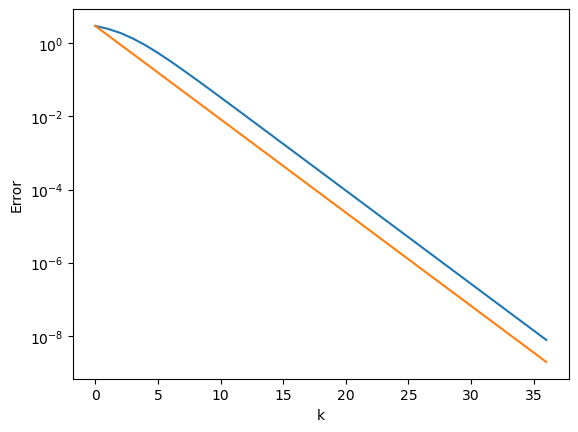

In [16]:
# Part (b)
A3 = np.array([[6, 1, 1, 1],
               [1, 6, 1, 1],
               [1, 1, 6, 1],
               [1, 1, 1, 6]])
x0_b = np.array([1.0 , 0.0, 0.0, 0.0])

lam, x, history = power_iteration(A3, x0_b)

print("Estimated lam:", round(lam, 4))
print("Estimated x:", x)

eigvals = np.linalg.eigvals(A3)
print("Eigenvalues using numpy:", eigvals)

idx1 = np.argmax(np.abs(eigvals))
lam1 = eigvals[idx1]

eigvals_abs = np.abs(eigvals)
eigvals_abs[idx1] = 0

idx2 = np.argmax(eigvals_abs)
lam2 = eigvals[idx2]

print("lam1:", lam1)
print("lam2:", lam2)

history = np.array(history)
error = np.abs(history - lam1)

k = np.arange(len(history))

C = error [0]
reference = C * (np.abs(lam2 / lam1) ** k)

plt.plot(k, error)
plt.plot(k, reference)
plt.yscale("log")
plt.xlabel("k")
plt.ylabel("Error")
plt.show()

In [20]:
# Problem 3
def gershgorin_disks(A):

    n = A.shape[0]
    centers = np.diag(A).astype(complex)
    radii = np.zeros(n)
    
    for i in range(n):
        radii[i] = np.sum(np.abs(A[i, :])) - np.abs(A[i,i])
        
    return centers, radii

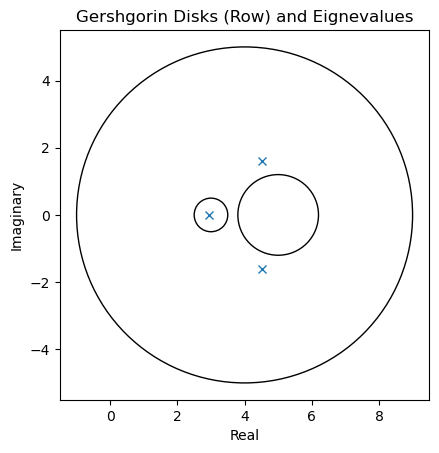

In [22]:
# Problem 3(a)
centers, radii = gershgorin_disks(A)
eigvals = np.linalg.eigvals(A)

fig, ax = plt.subplots()
for i in range(len(centers)):
    circle = patches.Circle((centers[i].real,0), radii[i], fill=False)

    ax.add_patch(circle)

ax.plot(eigvals.real, eigvals.imag, 'x')

ax.set_aspect('equal')
ax.set_xlabel("Real")
ax.set_ylabel("Imaginary")
ax.set_title("Gershgorin Disks (Row) and Eignevalues")
plt.show()

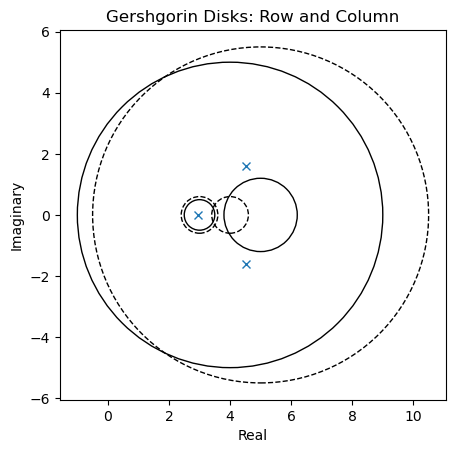

In [26]:
# Problem 3(b)
centers_row, radii_row = gershgorin_disks(A)
centers_col, radii_col = gershgorin_disks(A.T)

eigvals = np.linalg.eigvals(A)
fig, ax = plt.subplots()

for i in range(len(centers_row)):
    circle = patches.Circle((centers_row[i].real, 0),
                            radii_row[i],
                            fill=False)
    ax.add_patch(circle)

for i in range(len(centers_col)):
    circle = patches.Circle((centers_col[i].real, 0),
                            radii_col[i],
                            fill=False,
                            linestyle='--')
    ax.add_patch(circle)

ax.plot(eigvals.real, eigvals.imag, 'x')

ax.set_aspect('equal')
ax.set_xlabel("Real")
ax.set_ylabel("Imaginary")
ax.set_title("Gershgorin Disks: Row and Column")
plt.show()